In [5]:
import pandas as pd
import re
import string
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')
lemmatizer = WordNetLemmatizer()

# read data
df = pd.read_excel("https://raw.githubusercontent.com/FNXNRNJOYCE/HKU/main/7005/foxnews_articles_crawled.xlsx")

# look data
print("dataset row:", df.columns.tolist())
print("dataset first column:")
print(df.head())

# clean stop words
clean_words = set([
    'a', 'an', 'the', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by',
    'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did',
    'will', 'would', 'could', 'should', 'may', 'might', 'must', 'can',
    'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them',
    'this', 'that', 'these', 'those', 'my', 'your', 'his', 'her', 'its', 'our', 'their',
    'from', 'as', 'so', 'than', 'too', 'very', 'just', 'now', 'then', 'here', 'there',
    'when', 'where', 'why', 'how', 'what', 'which', 'who', 'whom',
    'also', 'however', 'therefore', 'moreover', 'furthermore', 'nevertheless',
    'said', 'says', 'according', 'like', 'time', 'people', 'year', 'years', 'new','not','about','after','all','abortion'
])

def clean_text(text):
    """
    clean data
    """
    if pd.isna(text):
        return ""
    
    # trensform to str
    text = str(text)
    
    # 1. to lower words
    text = text.lower()
    
    # 2. discard the punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 3. discard the numbers
    text = re.sub(r'\d+', '', text)
    
    # 4. split the word
    words = text.split()
    
    #5. Restore part of speech
    lemmatized_words = []
    for word in words:
        lemma = lemmatizer.lemmatize(lemmatizer.lemmatize(word, pos='v'), pos='n')
        lemmatized_words.append(lemma)
    
    # 6. discard the stop words and less than 2
    filtered_words = [
        word for word in lemmatized_words  
        if word not in clean_words and len(word) > 2
    ]
      # 7. join the words together again
    cleaned_text = ' '.join(filtered_words)
    
    # 8. clean the space
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    
    return cleaned_text

#select the column that want to clean
text_column = 'content'  


# clean data 
print(f"ceaning data: {text_column}")
df['cleaned_text'] = df[text_column].apply(clean_text)

# conpare the data
print("\n compare the data:")
print("=" * 50)
for i in range(min(3, len(df))):
    original_text = str(df[text_column].iloc[i])
    cleaned_text = df['cleaned_text'].iloc[i]
    
    print(f"sample {i+1} - the original sample:")
    print(original_text[:200] + "..." if len(original_text) > 200 else original_text)
    print(f"\nsample {i+1} - data cleaning after:")
    print(cleaned_text[:200] + "..." if len(cleaned_text) > 200 else cleaned_text)
    print("-" * 50)

# save the clean data
output_path = "fox_abortion_articles_us.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\n celan have save in: {output_path}")

# calcualte the information
original_avg_length = df[text_column].astype(str).apply(len).mean()
cleaned_avg_length = df['cleaned_text'].astype(str).apply(len).mean()


print(f"the original data lenth: {original_avg_length:.2f} ")
print(f"after: {cleaned_avg_length:.2f} ")
print(f"reduce: {((original_avg_length - cleaned_avg_length) / original_avg_length * 100):.2f}%")

[nltk_data] Downloading package wordnet to /Users/cyy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/cyy/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


dataset row: ['title', 'url', 'publish_time', 'content']
dataset first column:
                                               title  \
0  Pro-life influencer attacked in NYC files laws...   
1  Missouri attorney general takes new legal aim ...   
2  Pro-life pregnancy centers see client increase...   
3  Northwestern Student Committee gets donated ‘r...   
4    Record 40% of young women want to flee US: poll   

                                                 url  \
0  https://www.foxnews.com/media/pro-life-influen...   
1  https://www.foxnews.com/politics/missouri-atto...   
2  https://www.foxnews.com/politics/pro-life-preg...   
3  https://www.foxnews.com/media/northwestern-stu...   
4  https://www.foxnews.com/politics/record-40-you...   

                    publish_time  \
0   November 21, 2025 6:30am EST   
1  November 20, 2025 10:30pm EST   
2   November 17, 2025 4:31pm EST   
3  November 14, 2025 12:00pm EST   
4   November 13, 2025 7:52am EST   

                              

In [15]:
# make the pictures of mask
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFont


def create_fox_mask():
    fig, ax = plt.subplots(figsize=(20, 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.axis('off')
    
    ax.text(0.5, 0.5, 'FOX', 
            fontsize=300,
            ha='center', 
            va='center',
            color='black',
            fontweight='bold')  
    
    plt.savefig('temp_fox_mask.png', dpi=150, bbox_inches='tight', 
                facecolor='white', pad_inches=0)
    plt.close()
    
    mask = np.array(Image.open('temp_fox_mask.png'))
    return mask

fox_mask = create_fox_mask()

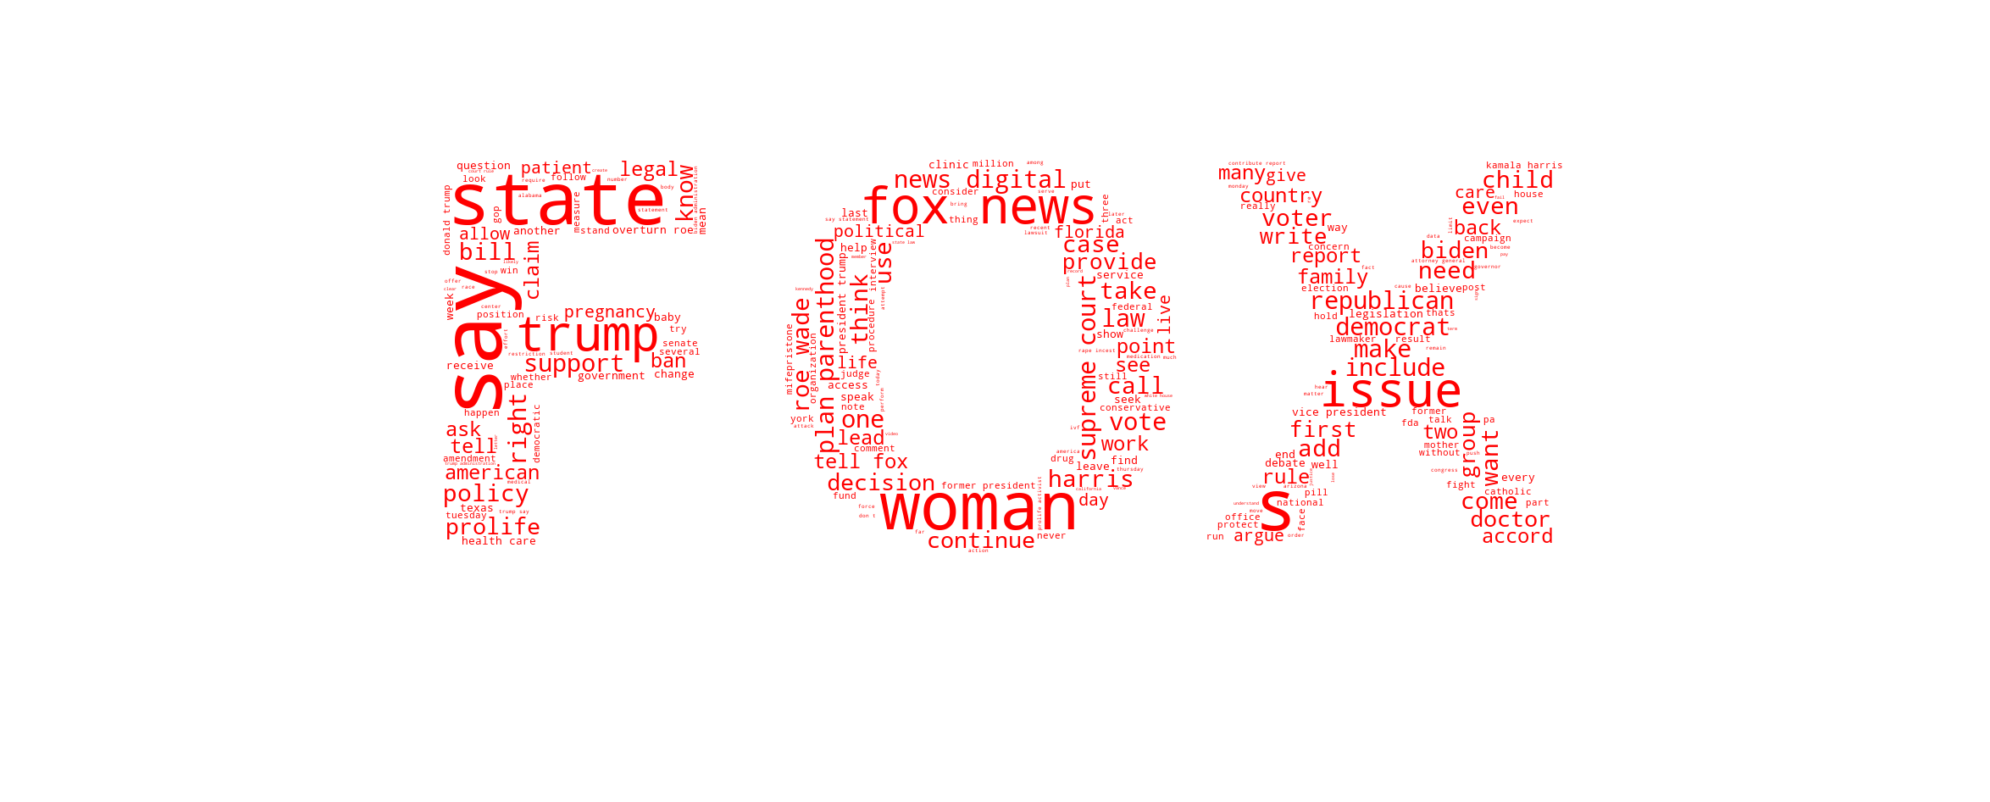

In [17]:
import pandas as pd
import re
import string
from wordcloud import WordCloud, get_single_color_func

df_clean = pd.read_csv("https://raw.githubusercontent.com/FNXNRNJOYCE/HKU/main/7005/fox_clean_word_frequency.csv", encoding="utf-8")
fox_text = ' '.join(df_clean['cleaned_text'].dropna())

def red_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "red"  


def red_colormap(word, font_size, position, orientation, random_state=None, **kwargs):

    if font_size > 80:
        return "#000080"  
    elif font_size > 40:
        return "#B22222"  
    else:
        return "#DC143C"  


wordcloud_fox = WordCloud(
    mask=fox_mask,
    background_color='white',
    color_func=red_color_func,   
    max_words=250,
    width=2000,
    height=1000,
    relative_scaling=0.3,
).generate(fox_text)


plt.figure(figsize=(20, 10))
plt.imshow(wordcloud_fox, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()


wordcloud_fox.to_file('fox_text_wordcloud.png')



have saved


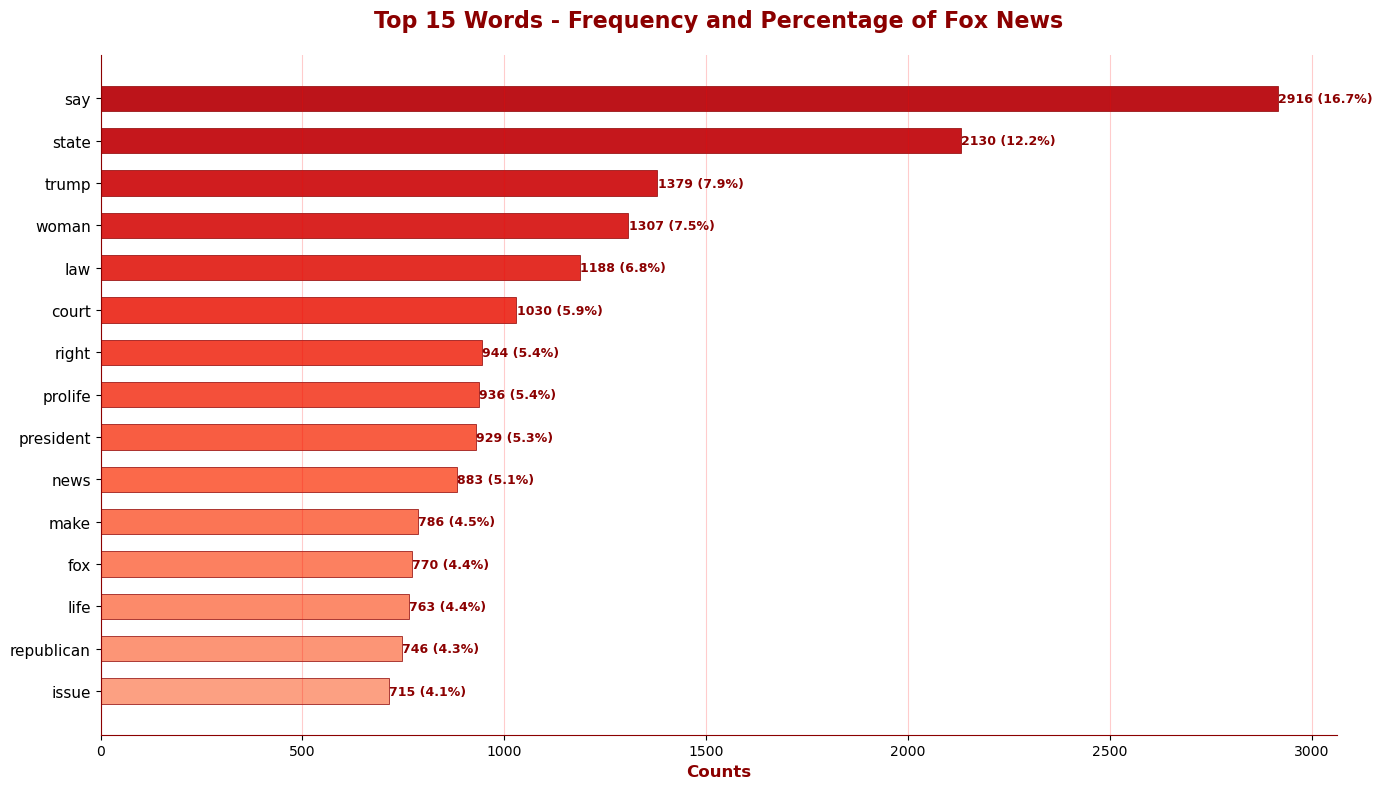

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# read the data
df_clean = pd.read_csv("https://raw.githubusercontent.com/FNXNRNJOYCE/HKU/main/7005/fox_clean_word_frequency.csv", encoding="utf-8")
# count word frequency
text = ' '.join(df['cleaned_text'].dropna().astype(str))
words = text.split()
word_freq = Counter(words)
top_words = word_freq.most_common(15)

# calculate the percentage
total_count = sum(count for word, count in top_words)
words, counts = zip(*top_words)
percentages = [count/total_count*100 for count in counts]

# create the graph
plt.figure(figsize=(14, 8))
colors = plt.cm.Reds([0.8 - i/(len(words)*2) for i in range(len(words))])

bars = plt.barh(range(len(words)), counts, color=colors, height=0.6, 
                edgecolor='darkred', linewidth=0.5)

plt.yticks(range(len(words)), words, fontsize=11)
plt.gca().invert_yaxis()
plt.xlabel('Counts', fontsize=12, fontweight='bold', color='darkred')
plt.title('Top 15 Words - Frequency and Percentage of Fox News', fontsize=16, fontweight='bold', 
          pad=20, color='darkred')

# show the percentage
for i, (count, percentage) in enumerate(zip(counts, percentages)):
    plt.text(count + 0.5, i, f'{count} ({percentage:.1f}%)', va='center', 
             fontsize=9, fontweight='bold', color='darkred')

# adjust some words
plt.grid(axis='x', alpha=0.2, color='red')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('darkred')
plt.gca().spines['bottom'].set_color('darkred')

plt.tight_layout()
plt.savefig("word_freq_percent_combo.png", dpi=300, bbox_inches='tight')
print("have saved")
plt.show()